# TRENDY Decadal NBP Maps

Spatial plots of decadal-mean Net Biome Productivity (NBP) from TRENDY v2025 model runs.

- **Data source**: `decadal_grids/` — decadal-mean NBP on a common 2°×2° grid
- **Experiments**: S0, S1, S2, S3
- **Units**: kg C m⁻² s⁻¹ (positive = land carbon sink)
- **Decades**: 1700–2020 (labelled by start year)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob
import re
from pathlib import Path

# ── Load all decadal grid files ──────────────────────────────────
files = sorted(glob.glob('decadal_grids/*_decadal_nbp.nc'))
print(f'Found {len(files)} decadal NetCDF files')

datasets = {}
for f in files:
    ds = xr.open_dataset(f)
    model = ds.attrs['model']
    exp   = ds.attrs['experiment']
    datasets[(model, exp)] = ds

models = sorted(set(k[0] for k in datasets))
experiments = ['S0', 'S1', 'S2', 'S3']
print(f'Models ({len(models)}): {", ".join(models)}')
print(f'Experiments: {experiments}')

# Unit conversion: kg C m-2 s-1 → g C m-2 yr-1
SEC_PER_YR = 365.25 * 24 * 3600
KG_TO_G = 1e3
UNIT_FACTOR = SEC_PER_YR * KG_TO_G  # multiply to get g C m-2 yr-1

Found 78 decadal NetCDF files
Models (20): CABLE-POP, CARDAMOM, CLASSIC, CLM-FATES, CLM6.0, DLEM, E3SM, EDv3, ELM-FATES, GDSTEM, IBIS, ISAM, JSBACH, JULES, LPJ-EOSIM, LPJ-GUESS, LPJmL, LPX-Bern, ORCHIDEE, VISIT-UT
Experiments: ['S0', 'S1', 'S2', 'S3']


## Multi-Model Mean Maps by Experiment — Recent Decades

Multi-model mean NBP for the most recent full decade (2010–2019) for each experiment.

/var/folders/pd/218my53900s1gy0k6lcyvjxm0000gn/T/ipykernel_23635/2779942963.py:26: RuntimeWarning: Mean of empty slice
  mmm = np.nanmean(stack, axis=0) * UNIT_FACTOR


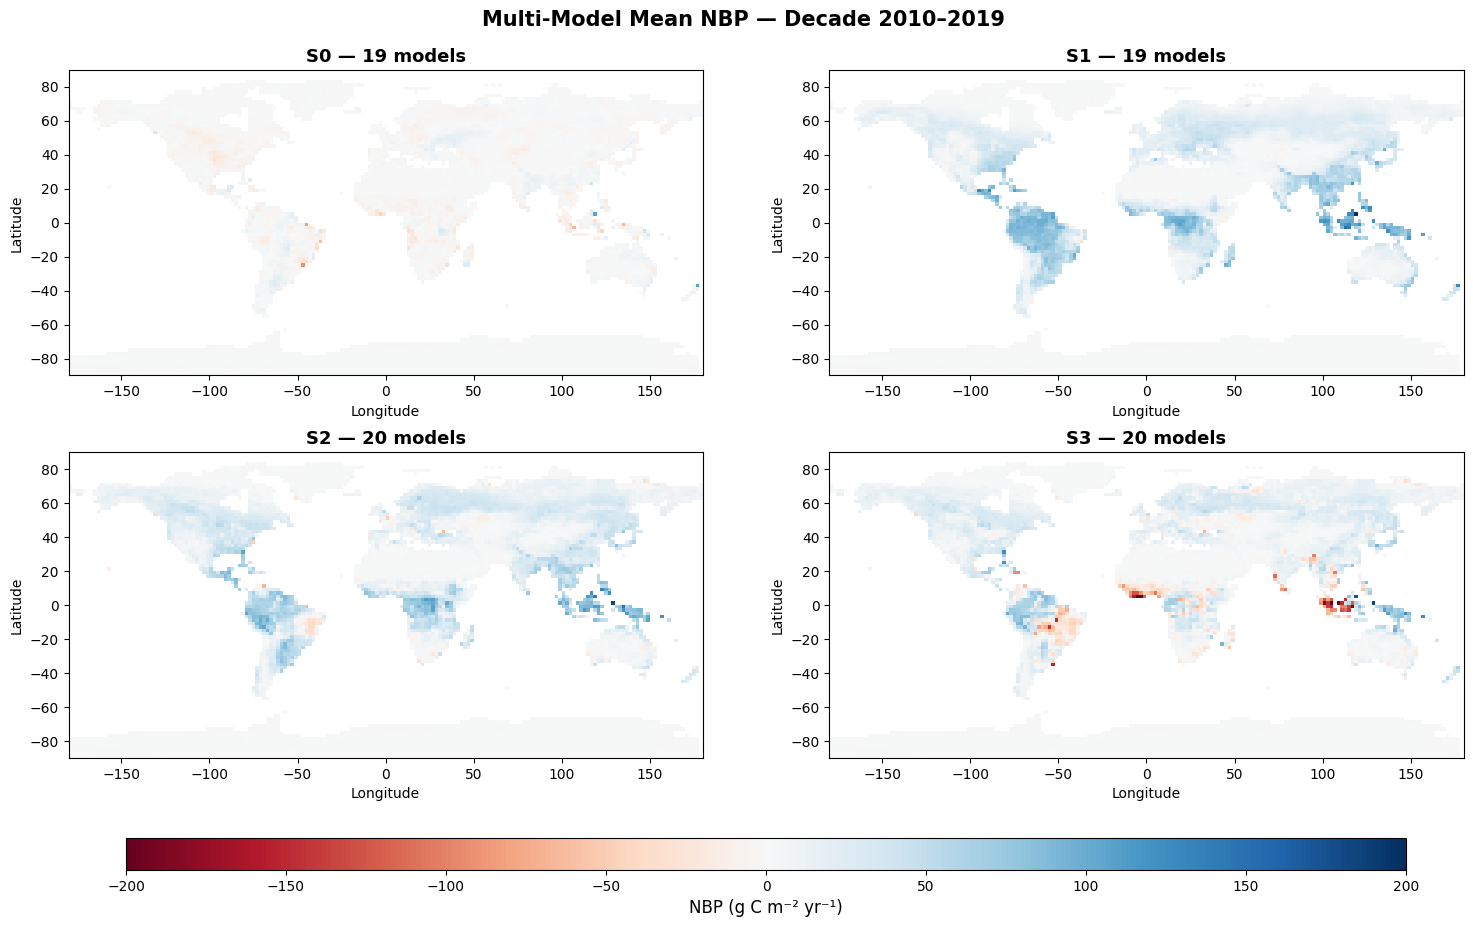

In [2]:
target_decade = 2010

fig, axes = plt.subplots(2, 2, figsize=(18, 10),
                         subplot_kw={'projection': None})

# Diverging colourmap centred on zero
vmax = 200  # g C m-2 yr-1
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = 'RdBu'

for ax, exp in zip(axes.flat, experiments):
    # Stack all models that have this experiment and decade
    fields = []
    for model in models:
        if (model, exp) in datasets:
            ds = datasets[(model, exp)]
            if target_decade in ds.decade.values:
                fields.append(ds['nbp'].sel(decade=target_decade).values)
    
    if len(fields) == 0:
        ax.set_title(f'{exp} — no data')
        continue
    
    # Multi-model mean
    stack = np.array(fields)  # (n_models, lat, lon)
    mmm = np.nanmean(stack, axis=0) * UNIT_FACTOR
    
    lat = datasets[list(datasets.keys())[0]].lat.values
    lon = datasets[list(datasets.keys())[0]].lon.values
    
    im = ax.pcolormesh(lon, lat, mmm, cmap=cmap, norm=norm, shading='auto')
    ax.set_title(f'{exp} — {len(fields)} models', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

fig.suptitle(f'Multi-Model Mean NBP — Decade {target_decade}–{target_decade+9}',
             fontsize=15, fontweight='bold')
fig.subplots_adjust(bottom=0.12, top=0.92, hspace=0.25)
cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.1, aspect=40)
cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=12)
plt.show()

## Temporal Evolution of Spatial Patterns — S3 (All Forcings)

Multi-model mean NBP maps for selected decades under S3 (full forcing).

/var/folders/pd/218my53900s1gy0k6lcyvjxm0000gn/T/ipykernel_23635/4152008786.py:27: RuntimeWarning: Mean of empty slice
  mmm = np.nanmean(np.array(fields), axis=0) * UNIT_FACTOR


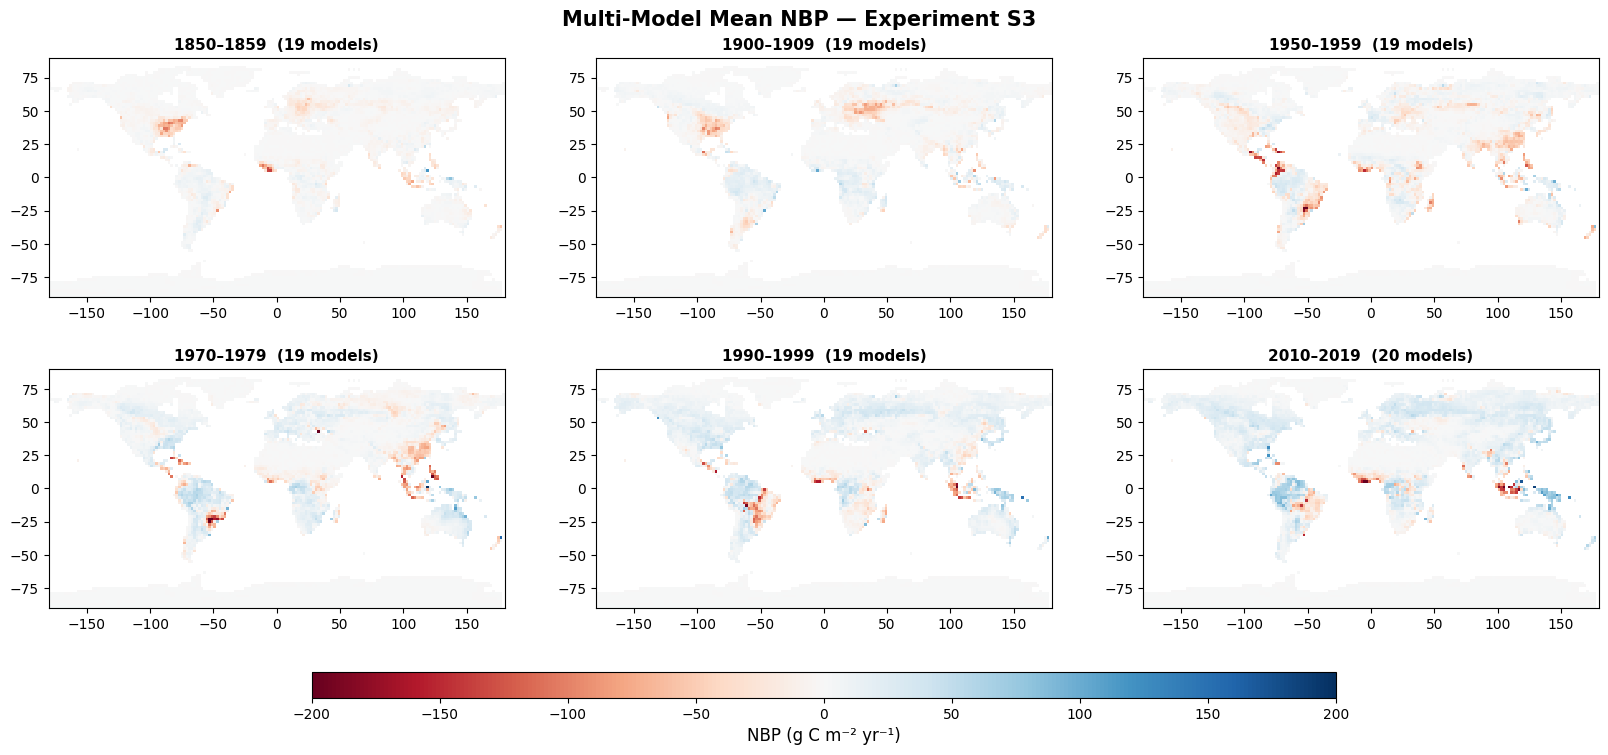

In [3]:
selected_decades = [1850, 1900, 1950, 1970, 1990, 2010]
exp = 'S3'

ncols = 3
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 8))

vmax = 200
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = 'RdBu'

lat = datasets[list(datasets.keys())[0]].lat.values
lon = datasets[list(datasets.keys())[0]].lon.values

for ax, dec in zip(axes.flat, selected_decades):
    fields = []
    for model in models:
        if (model, exp) in datasets:
            ds = datasets[(model, exp)]
            if dec in ds.decade.values:
                fields.append(ds['nbp'].sel(decade=dec).values)
    
    if len(fields) == 0:
        ax.set_title(f'{dec}s — no data')
        continue
    
    mmm = np.nanmean(np.array(fields), axis=0) * UNIT_FACTOR
    im = ax.pcolormesh(lon, lat, mmm, cmap=cmap, norm=norm, shading='auto')
    ax.set_title(f'{dec}–{dec+9}  ({len(fields)} models)', fontsize=11, fontweight='bold')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

fig.suptitle(f'Multi-Model Mean NBP — Experiment {exp}', fontsize=15, fontweight='bold')
fig.subplots_adjust(bottom=0.12, top=0.92, hspace=0.3)
cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.1, aspect=40)
cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=12)
plt.show()

## Land Use Effect Maps: S3 − S2

Multi-model mean difference S3 − S2 isolates the spatial fingerprint of land-use change.

/var/folders/pd/218my53900s1gy0k6lcyvjxm0000gn/T/ipykernel_23635/3429489916.py:26: RuntimeWarning: Mean of empty slice
  mmm_diff = np.nanmean(np.array(diffs), axis=0) * UNIT_FACTOR


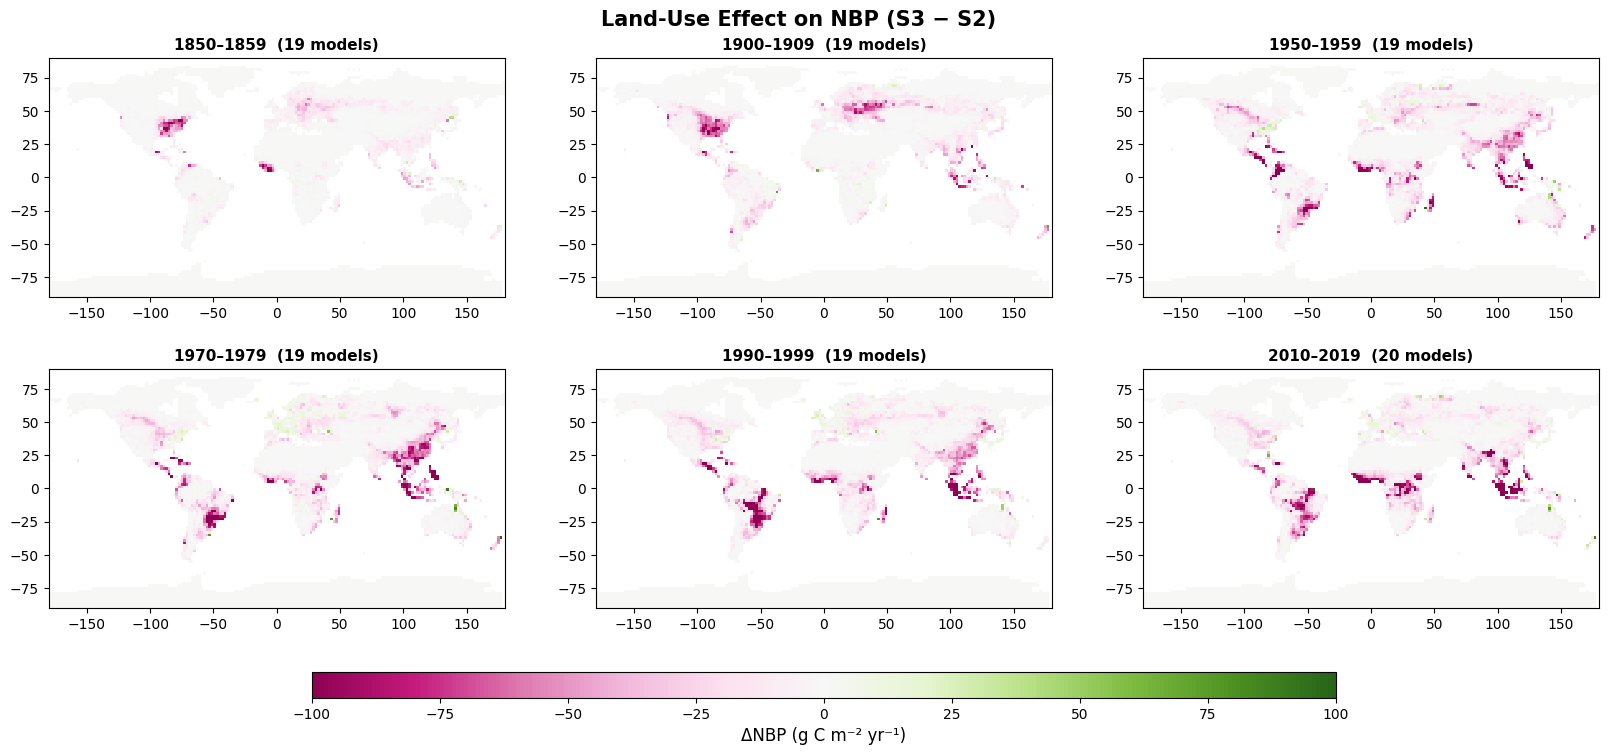

In [4]:
selected_decades_lu = [1850, 1900, 1950, 1970, 1990, 2010]

fig, axes = plt.subplots(2, 3, figsize=(20, 8))

vmax_lu = 100
norm_lu = mcolors.TwoSlopeNorm(vmin=-vmax_lu, vcenter=0, vmax=vmax_lu)
cmap_lu = 'PiYG'

lat = datasets[list(datasets.keys())[0]].lat.values
lon = datasets[list(datasets.keys())[0]].lon.values

for ax, dec in zip(axes.flat, selected_decades_lu):
    diffs = []
    for model in models:
        has_s3 = (model, 'S3') in datasets and dec in datasets[(model, 'S3')].decade.values
        has_s2 = (model, 'S2') in datasets and dec in datasets[(model, 'S2')].decade.values
        if has_s3 and has_s2:
            s3_field = datasets[(model, 'S3')]['nbp'].sel(decade=dec).values
            s2_field = datasets[(model, 'S2')]['nbp'].sel(decade=dec).values
            diffs.append(s3_field - s2_field)
    
    if len(diffs) == 0:
        ax.set_title(f'{dec}s — no data')
        continue
    
    mmm_diff = np.nanmean(np.array(diffs), axis=0) * UNIT_FACTOR
    im = ax.pcolormesh(lon, lat, mmm_diff, cmap=cmap_lu, norm=norm_lu, shading='auto')
    ax.set_title(f'{dec}–{dec+9}  ({len(diffs)} models)', fontsize=11, fontweight='bold')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

fig.suptitle('Land-Use Effect on NBP (S3 − S2)', fontsize=15, fontweight='bold')
fig.subplots_adjust(bottom=0.12, top=0.92, hspace=0.3)
cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.1, aspect=40)
cbar.set_label('ΔNBP (g C m⁻² yr⁻¹)', fontsize=12)
plt.show()

## Model Spread — Individual Model Maps (S3, 2010s)

NBP from each model for the 2010–2019 decade under S3 (all forcings).

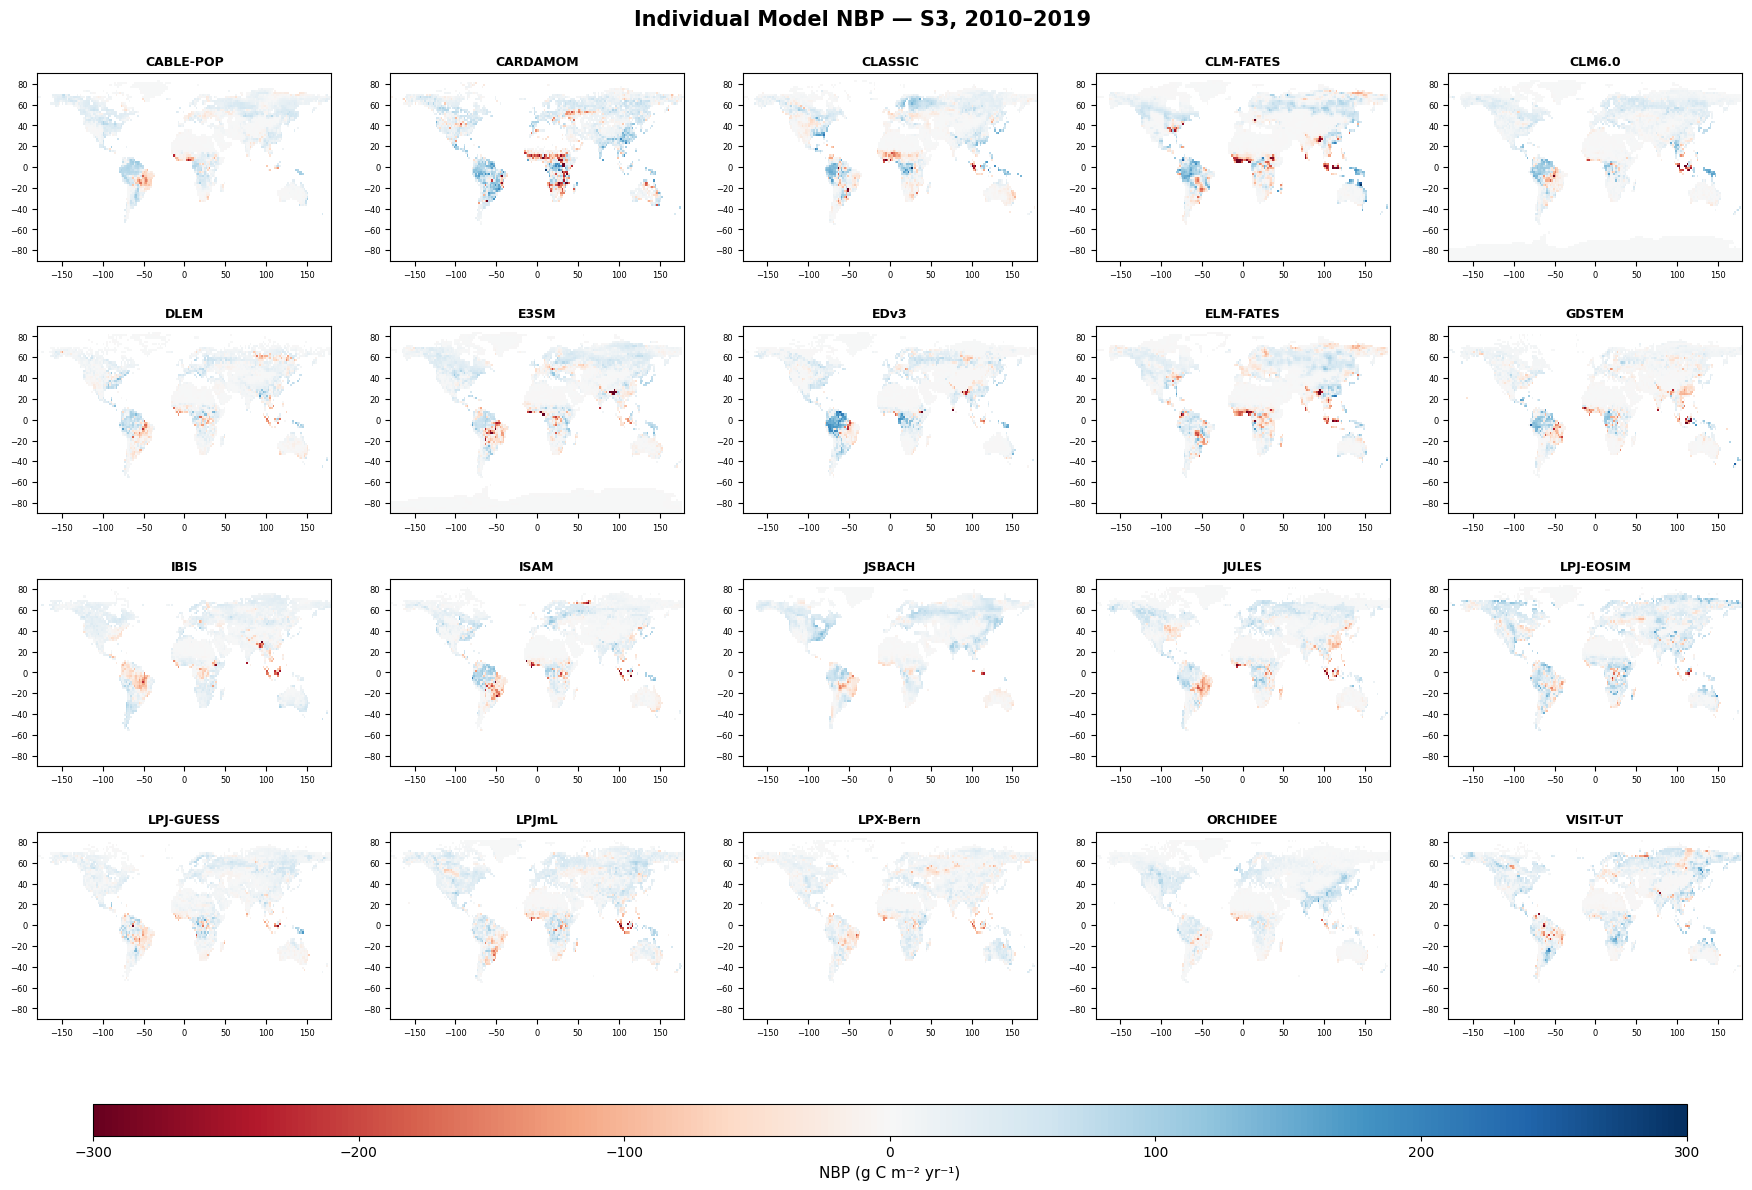

In [5]:
target_decade = 2010
exp = 'S3'

# Models that have S3 data for this decade
avail = [m for m in models
         if (m, exp) in datasets and target_decade in datasets[(m, exp)].decade.values]

ncols = 5
nrows = int(np.ceil(len(avail) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.2))

vmax = 300
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = 'RdBu'

lat = datasets[list(datasets.keys())[0]].lat.values
lon = datasets[list(datasets.keys())[0]].lon.values

for idx, model in enumerate(avail):
    ax = axes.flat[idx]
    field = datasets[(model, exp)]['nbp'].sel(decade=target_decade).values * UNIT_FACTOR
    im = ax.pcolormesh(lon, lat, field, cmap=cmap, norm=norm, shading='auto')
    ax.set_title(model, fontsize=9, fontweight='bold')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.tick_params(labelsize=6)

# Hide unused panels
for idx in range(len(avail), len(axes.flat)):
    axes.flat[idx].set_visible(False)

fig.suptitle(f'Individual Model NBP — {exp}, {target_decade}–{target_decade+9}',
             fontsize=15, fontweight='bold')
fig.subplots_adjust(bottom=0.1, top=0.93, hspace=0.35)
cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.03, pad=0.08, aspect=50)
cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=11)
plt.show()

In [7]:
from PIL import Image
import io

# Get all unique decades across S3 datasets
all_decades = set()
for model, exp in datasets:
    if exp == 'S3':
        all_decades.update(datasets[(model, exp)].decade.values)

all_decades = sorted(list(all_decades))
print(f"Available decades for S3: {all_decades}")

# Generate frames
frames = []
exp = 'S3'

lat = datasets[list(datasets.keys())[0]].lat.values
lon = datasets[list(datasets.keys())[0]].lon.values

vmax = 200
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = 'RdBu'

for decade in all_decades:
    # Collect fields from all models that have this decade and experiment
    fields = []
    for model in models:
        if (model, exp) in datasets:
            ds = datasets[(model, exp)]
            if decade in ds.decade.values:
                fields.append(ds['nbp'].sel(decade=decade).values)
    
    if len(fields) == 0:
        print(f"Skipping {decade}s — no S3 data")
        continue
    
    # Multi-model mean
    mmm = np.nanmean(np.array(fields), axis=0) * UNIT_FACTOR
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.pcolormesh(lon, lat, mmm, cmap=cmap, norm=norm, shading='auto')
    ax.set_title(f'Multi-Model Mean NBP — S3, {decade}–{decade+9}  ({len(fields)} models)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.04, pad=0.1)
    cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=11)
    
    # Save frame to memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf))
    plt.close(fig)

# Save as GIF
output_path = 'nbp_evolution_s3.gif'
if frames:
    frames[0].save(
        output_path,
        save_all=True,
        append_images=frames[1:],
        duration=500,  # 500 ms per frame
        loop=0  # infinite loop
    )
    print(f"✓ GIF saved to {output_path} ({len(frames)} frames)")
else:
    print("No frames generated!")


Available decades for S3: [np.int32(1690), np.int32(1700), np.int32(1710), np.int32(1720), np.int32(1730), np.int32(1740), np.int32(1750), np.int32(1760), np.int32(1770), np.int32(1780), np.int32(1790), np.int32(1800), np.int32(1810), np.int32(1820), np.int32(1830), np.int32(1840), np.int32(1850), np.int32(1860), np.int32(1870), np.int32(1880), np.int32(1890), np.int32(1900), np.int32(1910), np.int32(1920), np.int32(1930), np.int32(1940), np.int32(1950), np.int32(1960), np.int32(1970), np.int32(1980), np.int32(1990), np.int32(2000), np.int32(2010), np.int32(2020)]


/var/folders/pd/218my53900s1gy0k6lcyvjxm0000gn/T/ipykernel_23635/1253491904.py:38: RuntimeWarning: Mean of empty slice
  mmm = np.nanmean(np.array(fields), axis=0) * UNIT_FACTOR


✓ GIF saved to nbp_evolution_s3.gif (34 frames)


In [8]:
# Get all unique decades across S3 datasets
all_decades_s3 = set()
for model, exp in datasets:
    if exp == 'S3':
        all_decades_s3.update(datasets[(model, exp)].decade.values)

all_decades_s3 = sorted(list(all_decades_s3))

# Get models that have S3 data
models_s3 = [m for m in models if any((m, 'S3') in datasets for _ in [1])]
print(f"Models with S3 data: {len(models_s3)}")
print(f"Available decades: {all_decades_s3}")

# Generate frames
frames = []
exp = 'S3'

lat = datasets[list(datasets.keys())[0]].lat.values
lon = datasets[list(datasets.keys())[0]].lon.values

ncols = 5
nrows = int(np.ceil(len(models_s3) / ncols))

vmax = 300
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = 'RdBu'

for decade in all_decades_s3:
    # Create subplot grid for this decade
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.2))
    
    for idx, model in enumerate(models_s3):
        ax = axes.flat[idx]
        
        if (model, exp) in datasets and decade in datasets[(model, exp)].decade.values:
            field = datasets[(model, exp)]['nbp'].sel(decade=decade).values * UNIT_FACTOR
            im = ax.pcolormesh(lon, lat, field, cmap=cmap, norm=norm, shading='auto')
            ax.set_title(model, fontsize=9, fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(model, fontsize=9, fontweight='bold')
        
        ax.set_xlim(-180, 180)
        ax.set_ylim(-90, 90)
        ax.tick_params(labelsize=6)
    
    # Hide unused panels
    for idx in range(len(models_s3), len(axes.flat)):
        axes.flat[idx].set_visible(False)
    
    fig.suptitle(f'Individual Model NBP — S3, {decade}–{decade+9}',
                 fontsize=15, fontweight='bold')
    fig.subplots_adjust(bottom=0.1, top=0.93, hspace=0.35)
    cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                        fraction=0.03, pad=0.08, aspect=50)
    cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=11)
    
    # Save frame to memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf))
    plt.close(fig)

# Save as GIF
output_path = 'nbp_evolution_s3_models.gif'
if frames:
    frames[0].save(
        output_path,
        save_all=True,
        append_images=frames[1:],
        duration=500,  # 500 ms per frame
        loop=0  # infinite loop
    )
    print(f"✓ GIF saved to {output_path} ({len(frames)} frames)")
else:
    print("No frames generated!")


Models with S3 data: 20
Available decades: [np.int32(1690), np.int32(1700), np.int32(1710), np.int32(1720), np.int32(1730), np.int32(1740), np.int32(1750), np.int32(1760), np.int32(1770), np.int32(1780), np.int32(1790), np.int32(1800), np.int32(1810), np.int32(1820), np.int32(1830), np.int32(1840), np.int32(1850), np.int32(1860), np.int32(1870), np.int32(1880), np.int32(1890), np.int32(1900), np.int32(1910), np.int32(1920), np.int32(1930), np.int32(1940), np.int32(1950), np.int32(1960), np.int32(1970), np.int32(1980), np.int32(1990), np.int32(2000), np.int32(2010), np.int32(2020)]
✓ GIF saved to nbp_evolution_s3_models.gif (34 frames)


In [12]:
from ipywidgets import interact, IntSlider, Dropdown, VBox, Label
from IPython.display import display

# Get all unique decades and experiments
all_decades_interactive = sorted(list(set(
    d for model, exp in datasets 
    for d in datasets[(model, exp)].decade.values
)))

# Define geographic regions (lat_min, lat_max, lon_min, lon_max)
regions = {
    'Global': (-90, 90, -180, 180),
    'Western Europe': (35, 70, -10, 40),
    'Eastern Europe': (40, 70, 20, 60),
    'North America': (20, 85, -170, -50),
    'Central America': (7, 18, -92, -77),
    'South America': (-56, 13, -82, -34),
    'Africa': (-35, 37, -18, 52),
    'West Africa': (-5, 28, -20, 20),
    'East Africa': (-12, 5, 25, 42),
    'Asia': (-10, 55, 60, 150),
    'East Asia': (20, 55, 100, 145),
    'Southeast Asia': (-10, 20, 95, 145),
    'South Asia': (5, 37, 68, 98),
    'Australia': (-47, -10, 113, 154),
    'Arctic': (60, 90, -180, 180),
}

def plot_interactive(decade, experiment, source, region):
    """Plot NBP for selected decade, experiment, source, and geographic region."""
    lat = datasets[list(datasets.keys())[0]].lat.values
    lon = datasets[list(datasets.keys())[0]].lon.values
    
    vmax = 200
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = 'RdBu'
    
    # Get region bounds
    lat_min, lat_max, lon_min, lon_max = regions[region]
    
    if source == 'Multi-Model Mean':
        # Collect all models for this experiment/decade
        fields = []
        for model in models:
            if (model, experiment) in datasets:
                ds = datasets[(model, experiment)]
                if decade in ds.decade.values:
                    fields.append(ds['nbp'].sel(decade=decade).values)
        
        if len(fields) == 0:
            print(f"No data available for {experiment} in the {decade}s")
            return
        
        # Multi-model mean
        field_data = np.nanmean(np.array(fields), axis=0) * UNIT_FACTOR
        title = f'Multi-Model Mean NBP — {experiment}, {decade}–{decade+9}  ({len(fields)} models)'
        
        # Single plot
        fig, ax = plt.subplots(figsize=(14, 8))
        im = ax.pcolormesh(lon, lat, field_data, cmap=cmap, norm=norm, shading='auto')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        
        cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.04, pad=0.1)
        cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=11)
    
    elif source == 'All Models':
        # Get all available models for this experiment at this decade
        avail = [m for m in models 
                 if (m, experiment) in datasets and decade in datasets[(m, experiment)].decade.values]
        
        if len(avail) == 0:
            print(f"No data available for {experiment} in the {decade}s")
            return
        
        # Create subplot grid
        ncols = 5
        nrows = int(np.ceil(len(avail) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.2))
        
        vmax_grid = 300
        norm_grid = mcolors.TwoSlopeNorm(vmin=-vmax_grid, vcenter=0, vmax=vmax_grid)
        
        for idx, model in enumerate(avail):
            ax = axes.flat[idx]
            field = datasets[(model, experiment)]['nbp'].sel(decade=decade).values * UNIT_FACTOR
            im = ax.pcolormesh(lon, lat, field, cmap=cmap, norm=norm_grid, shading='auto')
            ax.set_title(model, fontsize=9, fontweight='bold')
            ax.set_xlim(lon_min, lon_max)
            ax.set_ylim(lat_min, lat_max)
            ax.tick_params(labelsize=6)
        
        # Hide unused panels
        for idx in range(len(avail), len(axes.flat)):
            axes.flat[idx].set_visible(False)
        
        fig.suptitle(f'Individual Model NBP — {experiment}, {decade}–{decade+9} ({region})',
                     fontsize=15, fontweight='bold')
        fig.subplots_adjust(bottom=0.1, top=0.93, hspace=0.35)
        cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                            fraction=0.03, pad=0.08, aspect=50)
        cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=11)
    
    else:
        # Specific model
        if (source, experiment) not in datasets:
            print(f"No data available for {source} in {experiment}")
            return
        
        ds = datasets[(source, experiment)]
        if decade not in ds.decade.values:
            print(f"No data available for {source} {experiment} in the {decade}s")
            return
        
        field_data = ds['nbp'].sel(decade=decade).values * UNIT_FACTOR
        title = f'NBP — {source} ({experiment}), {decade}–{decade+9}'
        
        # Single plot
        fig, ax = plt.subplots(figsize=(14, 8))
        im = ax.pcolormesh(lon, lat, field_data, cmap=cmap, norm=norm, shading='auto')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        
        cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.04, pad=0.1)
        cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Create interactive widgets
decade_slider = IntSlider(
    value=all_decades_interactive[len(all_decades_interactive)//2],
    min=min(all_decades_interactive),
    max=max(all_decades_interactive),
    step=10,
    description='Decade:',
    style={'description_width': '100px'},
    layout={'width': '400px'}
)

experiment_dropdown = Dropdown(
    options=['S0', 'S1', 'S2', 'S3'],
    value='S3',
    description='Experiment:',
    style={'description_width': '100px'}
)

source_options = ['Multi-Model Mean', 'All Models'] + sorted(models)
source_dropdown = Dropdown(
    options=source_options,
    value='Multi-Model Mean',
    description='Source:',
    style={'description_width': '100px'}
)

region_dropdown = Dropdown(
    options=list(regions.keys()),
    value='Global',
    description='Region:',
    style={'description_width': '100px'}
)

# Create interactive plot
interact(plot_interactive, 
         decade=decade_slider, 
         experiment=experiment_dropdown, 
         source=source_dropdown,
         region=region_dropdown)


interactive(children=(IntSlider(value=1860, description='Decade:', layout=Layout(width='400px'), max=2020, min…

<function __main__.plot_interactive(decade, experiment, source, region)>

## Interactive Multi-Model Mean NBP Explorer

Explore multi-model mean NBP across time and experiments with an interactive slider.


## Inter-Model Agreement

Fraction of models that agree on the **sign** of NBP (sink vs source) for the 2010s under S3. Values near 1 indicate strong agreement.

/var/folders/pd/218my53900s1gy0k6lcyvjxm0000gn/T/ipykernel_23635/2962567571.py:15: RuntimeWarning: Mean of empty slice
  mmm = np.nanmean(stack, axis=0)


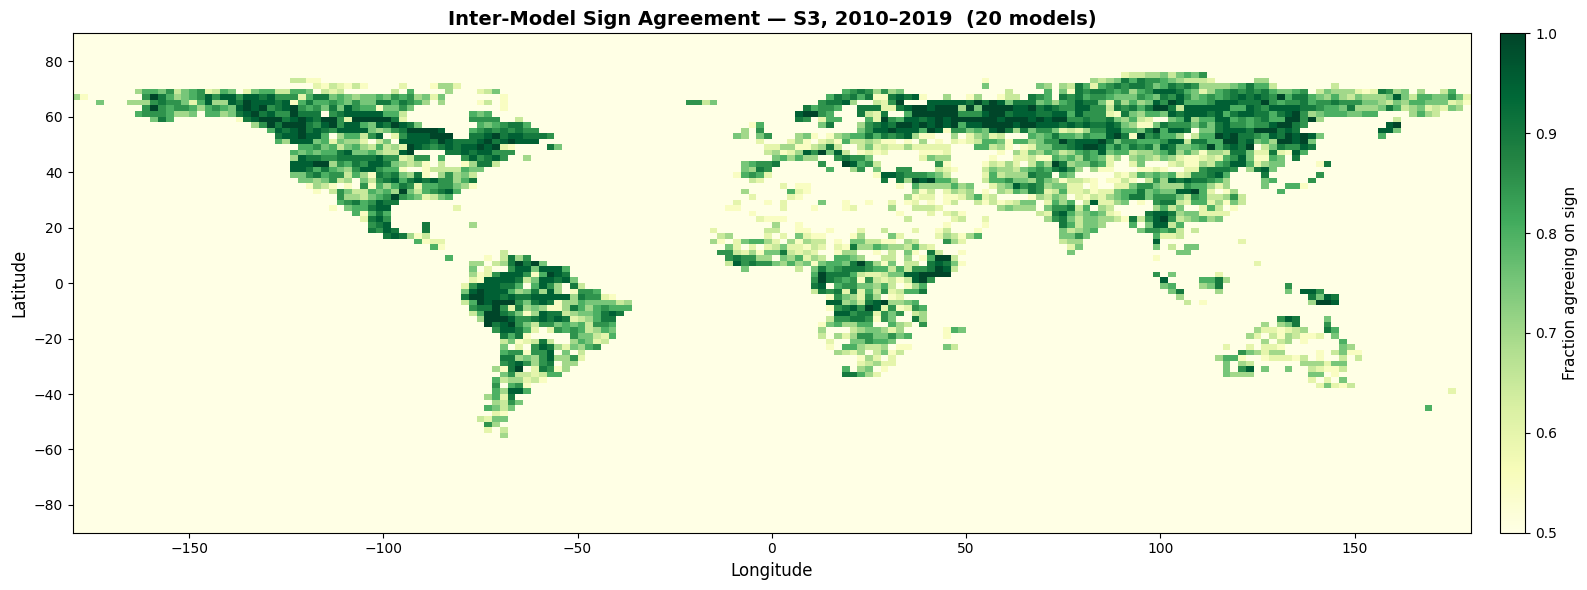

In [6]:
target_decade = 2010
exp = 'S3'

fields = []
for model in models:
    if (model, exp) in datasets:
        ds = datasets[(model, exp)]
        if target_decade in ds.decade.values:
            fields.append(ds['nbp'].sel(decade=target_decade).values)

stack = np.array(fields)  # (n_models, lat, lon)
n_models = stack.shape[0]

# Fraction agreeing on the sign of the multi-model mean
mmm = np.nanmean(stack, axis=0)
sign_mmm = np.sign(mmm)
agree = np.nansum(np.sign(stack) == sign_mmm[np.newaxis, :, :], axis=0) / n_models

lat = datasets[list(datasets.keys())[0]].lat.values
lon = datasets[list(datasets.keys())[0]].lon.values

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.pcolormesh(lon, lat, agree, cmap='YlGn', vmin=0.5, vmax=1.0, shading='auto')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(f'Inter-Model Sign Agreement — {exp}, {target_decade}–{target_decade+9}  ({n_models} models)',
             fontsize=14, fontweight='bold')
cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Fraction agreeing on sign', fontsize=11)
plt.tight_layout()
plt.show()